# Predicción de Volatilidad SP500 — Exploración de Datos y Selección de Modelo

**Metodología:** CRISP-DM (Cross-Industry Standard Process for Data Mining)
**Módulo:** 2 — Entrenamiento y Gestión del Modelo ML (MLOps)
**Entrada:** `processed_sp500.csv` generado por `DataPipeline` (Módulo 1)

---

> ⚠️ **Nota sobre los datos usados para validar este notebook.** Para entregarte
> este notebook ya ejecutado y libre de errores, lo corrí una vez sobre datos
> **simulados** (un proceso GARCH(1,1) sintético que respeta exactamente el
> esquema, tipos y estadística de `processed_sp500.csv`). El código no cambia
> en absoluto: cuando lo ejecutes con tu `processed_sp500.csv` real, basta con
> correr todas las celdas de nuevo y los resultados reflejarán el
> comportamiento real del S&P 500.

Este notebook cubre las fases de CRISP-DM que **no** están cubiertas por el
pipeline de ingesta (`DataPipeline`), el cual ya resuelve gran parte de la
fase de *Preparación de Datos* (limpieza, features, sin data leakage — RF01
a RF06). Aquí completamos:

| Fase CRISP-DM | Contenido de este notebook |
|---|---|
| 1. Comprensión del Negocio | Objetivo del modelo, variable target, criterios de éxito |
| 2. Comprensión de los Datos | EDA: distribución, estacionariedad, autocorrelación, correlaciones |
| 3. Preparación de los Datos | Split temporal train/test + diseño de Walk-Forward Validation |
| 4. Modelado | Ridge, Lasso, ElasticNet, árboles (RF09) + GARCH(1,1) baseline (RF10) |
| 5. Evaluación | RMSE, MAE (RF17), sesgo direccional (RF18), comparación vs. GARCH (RF19) |
| 6. Despliegue | Qué falta para producción (RF07, RF08, RF11) — se define según tu elección de modelo |


## Fase 1 — Comprensión del Negocio (Business Understanding)

**Problema:** un trader necesita saber, *antes* de que abra el mercado, qué
tan amplio va a ser el rango de precios (High − Low) del SP500 durante la
sesión de mañana, para dimensionar correctamente el riesgo de sus
operaciones (stops, tamaño de posición, expectativa de movimiento).

**Variable objetivo (`target`):** `ln(High_mañana) − ln(Low_mañana)`, el
*log-range* del día siguiente. Ya fue calculado por `DataPipeline`
(`preparation.py`) siguiendo RF02/RF03: usa únicamente información
disponible hasta el cierre de hoy para las features, y el valor a predecir
es estrictamente el de mañana (sin fuga de información).

**Criterio de éxito (ligado a RF17–RF19):**
- El modelo candidato debe reportar RMSE y MAE sobre un conjunto de
  validación temporalmente posterior a su entrenamiento (nunca aleatorio).
- Debe superar a un **modelo GARCH(1,1)** como baseline de referencia — si
  un modelo de ML no le gana a GARCH, no se justifica su complejidad
  adicional.
- Debe reportarse su **sesgo direccional** (RF18): en gestión de riesgo,
  subestimar la volatilidad de mañana es más peligroso que sobreestimarla,
  así que no basta con mirar el error promedio — hay que ver hacia
  dónde se equivoca el modelo.

**Restricción metodológica clave:** estamos trabajando con una serie de
tiempo. **No podemos usar K-Fold Cross-Validation estándar** porque
mezclaría información del futuro en el entrenamiento de folds "pasados"
(leakage temporal). La validación se hace con **Walk-Forward Validation**
(ver Fase 3).


In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
import json
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from arch import arch_model
import joblib

%matplotlib inline
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (11, 4.5)
RANDOM_STATE = 42

## Fase 2 — Comprensión de los Datos (Data Understanding)

### 2.1 Carga de datos y verificación del esquema versionado (RNF12)

Antes de explorar nada, verificamos que el dataset procesado coincida con
el esquema de features versionado por `DataPipeline` (`feature_schema.py`).
Si esto no coincidiera, cualquier modelo que entrenemos quedaría inválido
en cuanto `DataPipeline` cambie el esquema — por eso se valida *antes* de
tocar los datos, no después.

In [2]:
# Bootstrap: notebooks/ es hermano de src/, permite importar DataPipeline
SRC_DIR = (Path("..") / "src").resolve()
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from DataPipeline.feature_schema import FEATURE_COLUMNS, SCHEMA_VERSION

DATASET_NAME = "sp500"
PROCESSED_DATA_PATH = SRC_DIR / "data" / "processed" / "processed_sp500.csv"
SCHEMA_MANIFEST_PATH = SRC_DIR / "data" / "processed" / "sp500_schema.json"

manifest = json.loads(SCHEMA_MANIFEST_PATH.read_text())
expected_columns = FEATURE_COLUMNS[DATASET_NAME]

assert manifest["columns"] == expected_columns, (
    "El esquema de processed_sp500.csv no coincide con DataPipeline.feature_schema — "
    "RNF12: no se debe modelar sobre un esquema desactualizado."
)

print(f"Dataset:            {manifest['dataset']}")
print(f"Versión de esquema: {manifest['schema_version']}")
print(f"Hash de columnas:   {manifest['hash']}")
print(f"Columnas ({len(expected_columns)}): {expected_columns}")

Dataset:            sp500
Versión de esquema: 1.0.0
Hash de columnas:   db93aec9f8ef
Columnas (12): ['sp500_log_return', 'sp500_log_range', 'sp500_body_log', 'sp500_upper_wick_log', 'sp500_lower_wick_log', 'sp500_vol_5d', 'sp500_vol_10d', 'vix_log_close', 'vix_log_range', 'vix_log_return', 'day_of_week', 'target']


In [3]:
df = pd.read_csv(PROCESSED_DATA_PATH, index_col="date", parse_dates=["date"]).sort_index()
df.head()

,sp500_log_return,sp500_log_range,sp500_body_log,sp500_upper_wick_log,sp500_lower_wick_log,sp500_vol_5d,sp500_vol_10d,vix_log_close,vix_log_range,vix_log_return,day_of_week,target
date,,,,,,,,,,,,
2005-01-18,0.009628,0.013367,0.009628,0.000000,0.003738,0.007942,0.006923,2.523326,0.066822,0.003213,1,0.009721
2005-01-19,-0.009535,0.009721,-0.009535,0.000000,0.000186,0.008803,0.006550,2.578701,0.062472,0.055375,2,0.009508
2005-01-20,-0.007813,0.009508,-0.007813,0.000000,0.001694,0.009138,0.006911,2.626840,0.060625,0.048140,3,0.009909
2005-01-21,-0.006435,0.009909,-0.006435,0.003431,0.000043,0.008783,0.006953,2.664447,0.076132,0.037606,4,0.007943
2005-01-24,-0.003534,0.007943,-0.003534,0.004409,0.000000,0.007681,0.006976,2.684440,0.040116,0.019994,0,0.009025


### 2.2 Forma general, tipos y calidad básica

Verificamos tamaño del dataset, rango temporal cubierto, que el índice de
fechas esté ordenado y sin duplicados, y que no queden nulos (RF04 ya los
elimina en la extracción, y `_engineer_features` hace `dropna()` al final
por las ventanas rolling — pero lo confirmamos, nunca se asume).

In [4]:
print(f"Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}")
print(f"Rango de fechas: {df.index.min().date()} → {df.index.max().date()}")
print(f"¿Índice duplicado?: {df.index.duplicated().any()}")
print(f"¿Índice ordenado?: {df.index.is_monotonic_increasing}")
print()
print(df.dtypes)

Filas: 5,407  |  Columnas: 12
Rango de fechas: 2005-01-18 → 2026-07-16
¿Índice duplicado?: False
¿Índice ordenado?: True

sp500_log_return        float64
sp500_log_range         float64
sp500_body_log          float64
sp500_upper_wick_log    float64
sp500_lower_wick_log    float64
sp500_vol_5d            float64
sp500_vol_10d           float64
vix_log_close           float64
vix_log_range           float64
vix_log_return          float64
day_of_week               int64
target                  float64
dtype: object


In [5]:
missing = df.isna().sum()
if missing.any():
    print(missing[missing > 0])
else:
    print("Sin valores nulos — esperado: DataPreparer aplica dropna() tras el feature engineering (RF04).")

Sin valores nulos — esperado: DataPreparer aplica dropna() tras el feature engineering (RF04).


### 2.3 Estadística descriptiva

Un primer vistazo a escalas y dispersión de cada variable. Todas las
features del Bloque A/B están en escala logarítmica (retornos, rangos,
mechas) precisamente para que sean comparables entre sí y estacionarias
(ver Readme del Diccionario de Variables) — si viéramos aquí columnas con
escalas de miles (precios absolutos), sería señal de que se coló una
columna cruda que debió eliminarse en `preparation.py`.

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
sp500_log_return,5407.0,0.000342,0.012021,-0.127652,-0.004058,0.000737,0.005718,0.109572
sp500_log_range,5407.0,0.012155,0.009817,0.001456,0.006304,0.009517,0.014489,0.109041
sp500_body_log,5407.0,0.000199,0.010579,-0.091272,-0.003732,0.000584,0.005031,0.102457
sp500_upper_wick_log,5407.0,0.002334,0.003029,0.000000,0.000432,0.001458,0.003090,0.043963
sp500_lower_wick_log,5407.0,0.002974,0.003961,0.000000,0.000513,0.001944,0.004024,0.068364
sp500_vol_5d,5407.0,0.009401,0.007943,0.000530,0.004790,0.007409,0.011389,0.095935
sp500_vol_10d,5407.0,0.009717,0.007356,0.001459,0.005402,0.007801,0.011501,0.075383
vix_log_close,5407.0,2.879986,0.359639,2.212660,2.603430,2.823163,3.093992,4.415099
vix_log_range,5407.0,0.093950,0.060672,0.011375,0.056652,0.079090,0.112203,1.033247
vix_log_return,5407.0,0.000055,0.075771,-0.442449,-0.041596,-0.006266,0.034482,0.768245


### 2.4 Distribución de la variable objetivo (`target`)

El log-range no puede ser negativo por construcción (`High ≥ Low`) por lo
que se espera una distribución con **asimetría positiva** (cola derecha
larga: días de pánico con rangos extremos). Esto es importante porque
influye en qué tan bien va a funcionar una pérdida cuadrática (RMSE) — los
días extremos van a pesar desproporcionadamente en el entrenamiento.

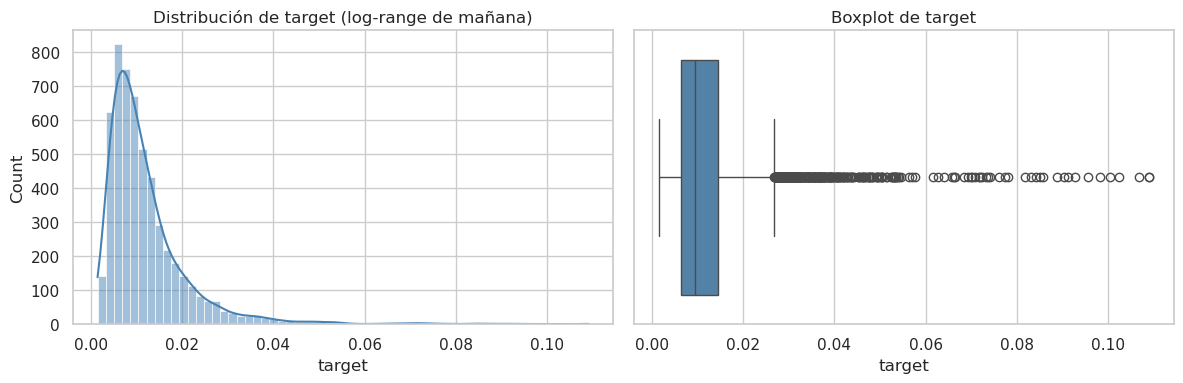

Asimetría (skew):  3.533
Curtosis (exceso): 20.474


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["target"], bins=60, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribución de target (log-range de mañana)")
sns.boxplot(x=df["target"], ax=axes[1], color="steelblue")
axes[1].set_title("Boxplot de target")
plt.tight_layout()
plt.show()

print(f"Asimetría (skew):  {skew(df['target']):.3f}")
print(f"Curtosis (exceso): {kurtosis(df['target']):.3f}")

### 2.5 Comportamiento en el tiempo — clustering de volatilidad

Graficamos el target a lo largo del tiempo. Buscamos confirmar el
fenómeno de **volatility clustering**: los períodos de alta volatilidad
tienden a agruparse (no están distribuidos aleatoriamente en el tiempo).
Esta es la premisa estadística detrás de `sp500_vol_5d`, `sp500_vol_20d`
como features, y también la premisa que justifica usar un modelo GARCH
como baseline (GARCH fue diseñado exactamente para capturar este
patrón).

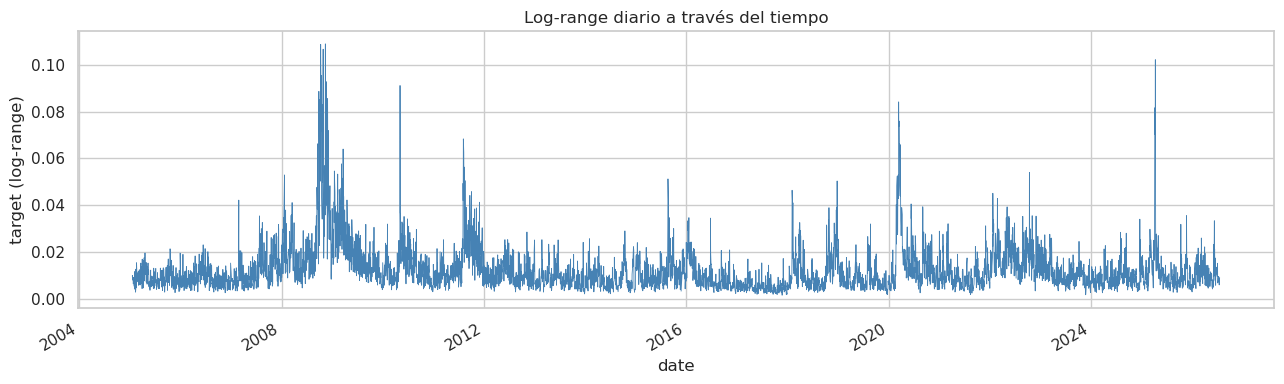

In [8]:
fig, ax = plt.subplots(figsize=(13, 4))
df["target"].plot(ax=ax, linewidth=0.6, color="steelblue")
ax.set_title("Log-range diario a través del tiempo")
ax.set_ylabel("target (log-range)")
plt.tight_layout()
plt.show()

### 2.6 Estacionariedad (Test de Dickey-Fuller Aumentado)

Para que un modelo estadístico/ML generalice en el tiempo, sus variables
de entrada y la variable objetivo deben ser **estacionarias** (media y
varianza estables, sin tendencia). Ya diseñamos las features en log-ratio
específicamente para lograr esto (ver Readme del proyecto) — el ADF test
lo confirma de forma cuantitativa en vez de asumirlo.

- H0: la serie tiene raíz unitaria (**no** es estacionaria).
- Si `p_value < 0.05` → rechazamos H0 → la serie **es estacionaria**.

In [9]:
def adf_report(series: pd.Series, name: str) -> dict:
    stat, p_value, *_ = adfuller(series.dropna(), autolag="AIC")
    return {"variable": name, "adf_stat": stat, "p_value": p_value, "estacionaria (5%)": p_value < 0.05}

columns_to_test = ["target", "sp500_log_range", "sp500_vol_5d", "sp500_log_return", "vix_log_close"]
adf_results = pd.DataFrame([adf_report(df[c], c) for c in columns_to_test])
adf_results

,variable,adf_stat,p_value,estacionaria (5%)
0,target,-6.284006,3.736410e-08,True
1,sp500_log_range,-6.279095,3.835541e-08,True
2,sp500_vol_5d,-6.512326,1.092597e-08,True
3,sp500_log_return,-16.497577,2.163533e-29,True
4,vix_log_close,-5.381270,3.707926e-06,True


### 2.7 Autocorrelación (ACF / PACF) del target

La función de autocorrelación (ACF) mide qué tanto el valor de hoy se
parece a los de N días atrás. Un decaimiento lento y positivo en varios
rezagos es la firma estadística del volatility clustering, y es lo que le
da poder predictivo a features como `sp500_vol_5d`/`sp500_vol_10d`
(memoria de corto plazo de la volatilidad).

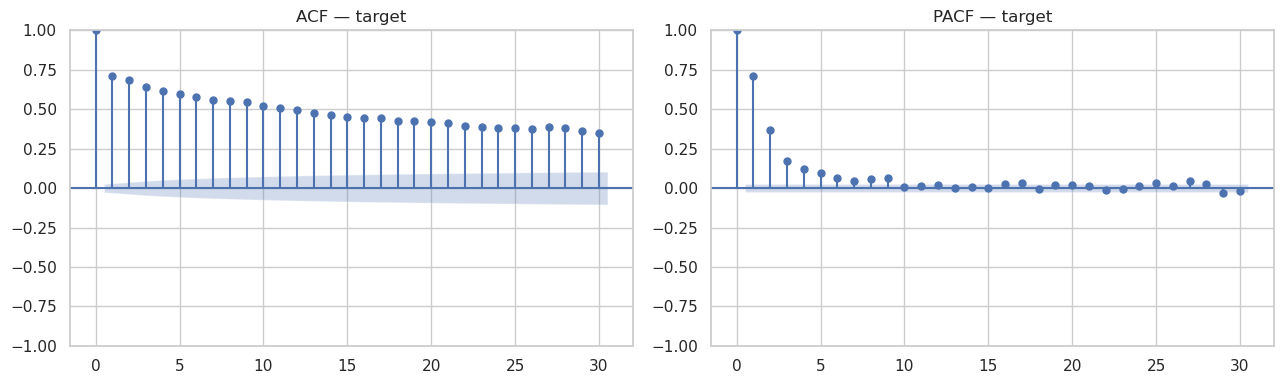

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(df["target"], lags=30, ax=axes[0])
axes[0].set_title("ACF — target")
plot_pacf(df["target"], lags=30, ax=axes[1], method="ywm")
axes[1].set_title("PACF — target")
plt.tight_layout()
plt.show()

### 2.8 Correlación entre features y con el target

Buscamos dos cosas: (1) qué features tienen mayor relación lineal con el
target — una primera pista de poder predictivo — y (2) multicolinealidad
entre features (por ejemplo `sp500_vol_5d` y `sp500_vol_10d` deberían
estar correlacionadas entre sí por construcción, lo cual es aceptable para
modelos de árboles pero relevante para los modelos lineales
regularizados que usaremos — Ridge/Lasso/ElasticNet manejan esto
naturalmente vía regularización, por eso los preferimos sobre una
regresión lineal simple).

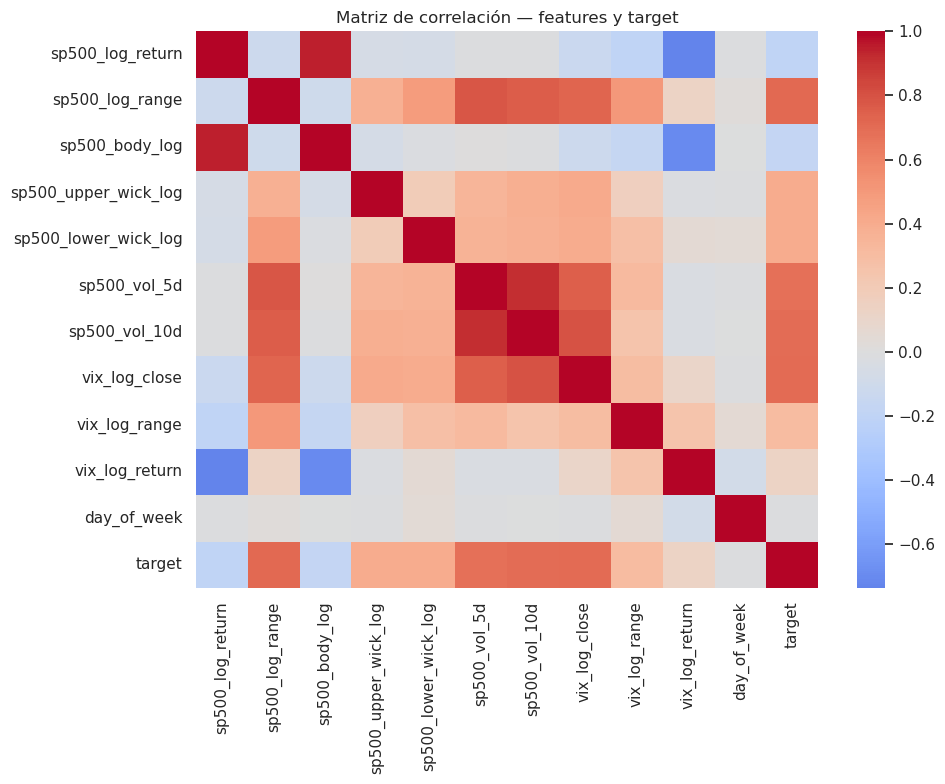

sp500_log_range         0.708287
vix_log_close           0.706308
sp500_vol_10d           0.700721
sp500_vol_5d            0.677920
sp500_lower_wick_log    0.401769
sp500_upper_wick_log    0.397484
vix_log_range           0.307557
sp500_log_return       -0.194755
sp500_body_log         -0.177454
vix_log_return          0.126109
day_of_week            -0.017666
Name: target, dtype: float64

In [11]:
corr = df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Matriz de correlación — features y target")
plt.tight_layout()
plt.show()

corr["target"].drop("target").sort_values(key=abs, ascending=False)

### 2.9 Efecto calendario (`day_of_week`)

Verificamos si el día de la semana tiene alguna relación visible con el
rango de mañana (justificación de negocio para `day_of_week` en el Readme:
ajustes de flujos los lunes, cierres de posición los viernes).

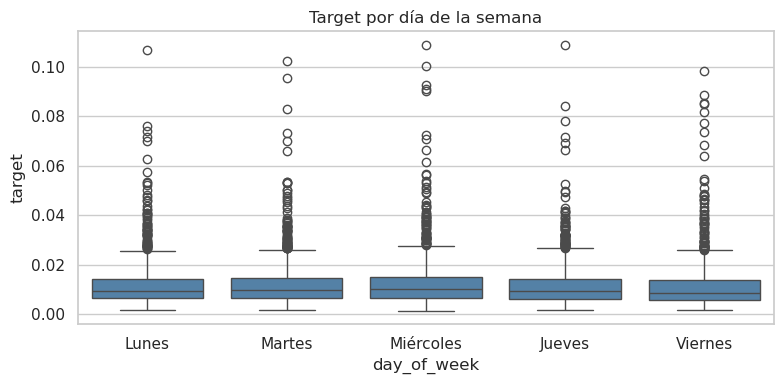

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_df = df.reset_index()
sns.boxplot(x="day_of_week", y="target", data=plot_df, ax=ax, color="steelblue")
ax.set_xticks(range(5))
ax.set_xticklabels(["Lunes", "Martes", "Miércoles", "Jueves", "Viernes"])
ax.set_title("Target por día de la semana")
plt.tight_layout()
plt.show()

### 2.10 Conclusiones de la Fase 2 (EDA)

- El target es no-negativo, con asimetría positiva → coherente con su
  definición matemática, no hay anomalías.
- Se confirma **volatility clustering** visualmente y vía ACF/PACF → los
  días de alta/baja volatilidad se agrupan, lo que justifica tanto las
  features de volatilidad rolling como el baseline GARCH.
- El target y las features clave son **estacionarias** (ADF) → viable
  modelar sin necesidad de diferenciar o des-tendenciar.
- Existe correlación esperada entre bloques de features relacionados
  (ej. `sp500_vol_5d` / `sp500_vol_10d`, `vix_log_close` con el nivel de
  miedo) → los modelos regularizados (Ridge/Lasso/ElasticNet) son
  apropiados frente a esta multicolinealidad.
- No hay un efecto calendario dominante, pero se deja la variable — no
  hace daño y captura señal marginal.


## Fase 3 — Preparación de los Datos para Modelado

`DataPipeline` ya resolvió la preparación de *features* (RF01–RF06). Lo
que falta es preparar la **estrategia de partición y validación**, que es
donde una serie de tiempo exige un tratamiento distinto al de un dataset
tabular convencional.

### 3.1 Por qué no usamos K-Fold Cross-Validation

En K-Fold estándar, los folds se arman aleatoriamente. Con una serie de
tiempo eso es un error metodológico grave: un fold de "entrenamiento"
podría contener datos de *después* del fold de "test", filtrando
información del futuro al pasado (la volatilidad de la próxima semana no
puede ayudar a predecir la de la semana pasada — en producción esa
información jamás va a estar disponible). El modelo mediría un desempeño
artificialmente bueno que no se replicaría en producción.

### 3.2 Estrategia de partición

1. **Holdout final (test):** el último ~15% de la serie, cronológicamente
   posterior a todo lo demás. Se toca **una sola vez**, al final, para
   reportar el desempeño final de cada candidato (Fase 5) y compararlo
   contra GARCH (RF19). Nunca se usa para elegir hiperparámetros — eso
   sería "espiar" el test set.
2. **Train/Validation (el resto, ~85%):** sobre este bloque se aplica
   **Walk-Forward Validation** para seleccionar modelos e hiperparámetros
   de forma honesta.

In [13]:
feature_columns = [c for c in FEATURE_COLUMNS[DATASET_NAME] if c != "target"]
X = df[feature_columns]
y = df["target"]

TEST_HOLDOUT_FRACTION = 0.15
split_idx = int(len(df) * (1 - TEST_HOLDOUT_FRACTION))

X_train_val, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train_val, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train/Val:     {X_train_val.shape[0]:,} filas  ({X_train_val.index.min().date()} → {X_train_val.index.max().date()})")
print(f"Test holdout:  {X_test.shape[0]:,} filas  ({X_test.index.min().date()} → {X_test.index.max().date()})")

Train/Val:     4,595 filas  (2005-01-18 → 2023-04-19)
Test holdout:  812 filas  (2023-04-20 → 2026-07-16)


### 3.3 Walk-Forward Validation

La idea: entrenar con todo lo disponible **hasta cierto punto**, evaluar
sobre el bloque inmediatamente siguiente (nunca visto), y luego **expandir**
la ventana de entrenamiento para incluir ese bloque y repetir. Así se
simula, dentro del propio histórico, el mismo régimen que tendrá el
modelo en producción bajo RF08 (reentrenamiento periódico, mensual por
defecto): en cada "mes" solo se sabe lo que pasó hasta ese mes.

Cada fold reporta sus propias métricas; el desempeño de un modelo se
resume como el **promedio ± desviación estándar** entre folds — un
modelo bueno debe ser consistente entre folds, no solo bueno en promedio.

In [14]:
def walk_forward_splits(n_samples: int, initial_train_size: int, step_size: int, min_test_size: int = 1):
    # Ventana de entrenamiento EXPANSIVA: el bloque de test es siempre
    # estrictamente posterior en el tiempo al de train (RF03 aplicado
    # también a la validación, no solo a las features).
    train_end = initial_train_size
    while train_end + min_test_size <= n_samples:
        test_end = min(train_end + step_size, n_samples)
        yield np.arange(0, train_end), np.arange(train_end, test_end)
        train_end = test_end

Folds de walk-forward generados: 66


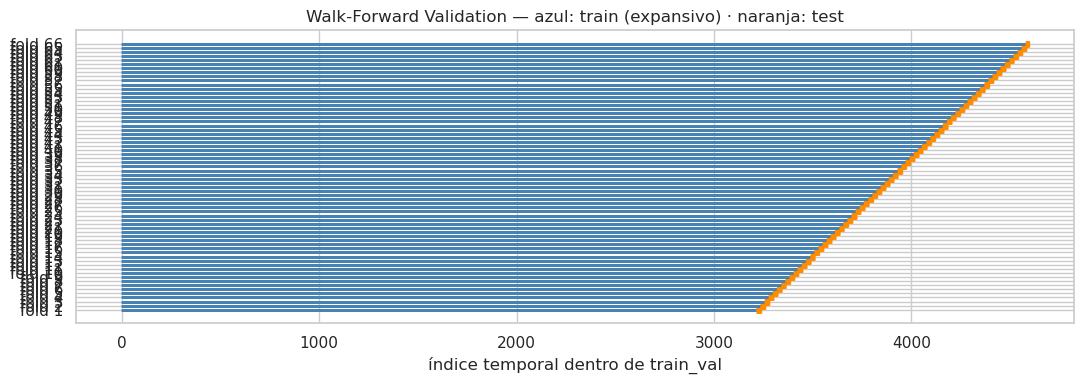

In [15]:
N = len(X_train_val)
INITIAL_TRAIN_SIZE = int(N * 0.70)
STEP_SIZE = 21  # ~1 mes de trading — coincide con la periodicidad por defecto de RF08

folds = list(walk_forward_splits(N, INITIAL_TRAIN_SIZE, STEP_SIZE))
print(f"Folds de walk-forward generados: {len(folds)}")

fig, ax = plt.subplots(figsize=(11, 4))
for i, (tr, te) in enumerate(folds):
    ax.plot(tr, [i] * len(tr), "|", color="steelblue", markersize=2)
    ax.plot(te, [i] * len(te), "|", color="darkorange", markersize=4)
ax.set_yticks(range(len(folds)))
ax.set_yticklabels([f"fold {i+1}" for i in range(len(folds))])
ax.set_xlabel("índice temporal dentro de train_val")
ax.set_title("Walk-Forward Validation — azul: train (expansivo) · naranja: test")
plt.tight_layout()
plt.show()

### 3.4 Escalado de features

Ridge/Lasso/ElasticNet son sensibles a la escala de las variables (la
penalización de regularización trata todos los coeficientes por igual, así
que una feature con magnitud mayor sería penalizada de forma
desproporcionada). Los modelos de árboles no lo necesitan (dividen por
umbrales, no por distancias).

**Regla de oro para evitar leakage:** el `StandardScaler` se ajusta
(`fit`) **solo con el fold de entrenamiento**, nunca con el de test —
igual que haríamos con el train/test global.

### 3.5 Métricas de evaluación

Definimos aquí las funciones que usaremos en todos los modelos, para que
la comparación sea consistente:
- **RMSE / MAE** (RF17): error estándar de regresión.
- **Sesgo direccional** (RF18): distingue subestimación (predicción por
  debajo del rango real — el riesgo más peligroso operacionalmente) de
  sobreestimación (predicción por encima).

In [16]:
def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def directional_bias_metrics(y_true, y_pred) -> dict:
    # RF18: subestimación = predicción < real (el modelo dice que mañana
    # será más tranquilo de lo que realmente fue). Sobreestimación =
    # predicción > real (el modelo es conservador de más).
    error = np.asarray(y_pred) - np.asarray(y_true)
    under, over = error[error < 0], error[error > 0]
    return {
        "bias_medio": float(error.mean()),
        "pct_subestimado": float((error < 0).mean() * 100),
        "pct_sobreestimado": float((error > 0).mean() * 100),
        "magnitud_media_subestimacion": float(-under.mean()) if len(under) else 0.0,
        "magnitud_media_sobreestimacion": float(over.mean()) if len(over) else 0.0,
    }


def evaluate_sklearn_walk_forward(model_ctor, X, y, folds, scale: bool) -> pd.DataFrame:
    # model_ctor: callable sin argumentos que retorna una instancia NUEVA
    # del estimador en cada fold (evita reusar estado entrenado entre folds).
    fold_metrics = []
    for train_idx, test_idx in folds:
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

        if scale:
            scaler = StandardScaler().fit(X_tr)
            X_tr, X_te = scaler.transform(X_tr), scaler.transform(X_te)

        model = model_ctor()
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)

        fold_metrics.append({
            "rmse": rmse(y_te, y_pred),
            "mae": mean_absolute_error(y_te, y_pred),
            **directional_bias_metrics(y_te, y_pred),
        })
    return pd.DataFrame(fold_metrics)


def grid_search_walk_forward(model_ctor_factory, grid, X, y, folds, scale: bool) -> pd.DataFrame:
    # Recorre una grilla de hiperparámetros, evaluando cada combinación
    # con walk-forward, y ordena por RMSE promedio ascendente.
    rows = []
    for params in grid:
        cv_df = evaluate_sklearn_walk_forward(lambda p=params: model_ctor_factory(**p), X, y, folds, scale=scale)
        rows.append({
            "params": params,
            "mean_rmse": cv_df["rmse"].mean(), "std_rmse": cv_df["rmse"].std(),
            "mean_mae": cv_df["mae"].mean(),
        })
    return pd.DataFrame(rows).sort_values("mean_rmse").reset_index(drop=True)

## Fase 4 — Modelado

Por requerimiento (RF09, RF10) entrenamos y comparamos:
1. **GARCH(1,1)** — baseline estadístico clásico de volatilidad.
2. **Ridge, Lasso, ElasticNet** — modelos lineales regularizados.
3. **Random Forest y Gradient Boosting** — modelos basados en árboles.

Cada familia se evalúa con la **misma** función de walk-forward y las
**mismas** métricas, para que la comparación en la Fase 5 sea justa.

### 4.1 Baseline — GARCH(1,1) (RF10)

GARCH modela la **varianza condicional de los retornos**
(`sp500_log_return`), no directamente el log-range. Para llevarlo a la
misma escala que nuestro target usamos la relación empírica entre rango y
volatilidad (estimador tipo Parkinson): ajustamos una regresión lineal
simple `target ≈ a·σ + b` usando **solo el fold de entrenamiento**, y
aplicamos esa calibración al pronóstico de σ del fold de test. Así GARCH
compite en igualdad de condiciones frente a los modelos de ML — nunca ve
el fold de test antes de predecirlo.

In [17]:
def evaluate_garch_walk_forward(returns: pd.Series, target: pd.Series, folds) -> pd.DataFrame:
    fold_metrics = []
    for train_idx, test_idx in folds:
        r_train = returns.iloc[train_idx] * 100  # arch converge mejor en escala %
        y_train, y_test = target.iloc[train_idx], target.iloc[test_idx]

        am = arch_model(r_train, vol="GARCH", p=1, q=1, dist="normal", mean="Zero", rescale=False)
        res = am.fit(disp="off")

        sigma_in_sample = res.conditional_volatility / 100
        calib = np.polyfit(sigma_in_sample, y_train.values, 1)  # target ≈ a*sigma + b, fit solo en train

        forecast = res.forecast(horizon=len(test_idx), reindex=False)
        sigma_forecast = np.sqrt(forecast.variance.values[-1]) / 100
        y_pred = np.polyval(calib, sigma_forecast)

        fold_metrics.append({
            "rmse": rmse(y_test, y_pred),
            "mae": mean_absolute_error(y_test, y_pred),
            **directional_bias_metrics(y_test, y_pred),
        })
    return pd.DataFrame(fold_metrics)


garch_cv = evaluate_garch_walk_forward(df["sp500_log_return"].loc[X_train_val.index], y_train_val, folds)
garch_summary = pd.DataFrame([{
    "params": {"p": 1, "q": 1},
    "mean_rmse": garch_cv["rmse"].mean(), "std_rmse": garch_cv["rmse"].std(),
    "mean_mae": garch_cv["mae"].mean(),
}])
garch_summary

,params,mean_rmse,std_rmse,mean_mae
0,"{'p': 1, 'q': 1}",0.007609,0.005645,0.006262


### 4.2 Modelos lineales regularizados (RF09)

Probamos una grilla pequeña de hiperparámetros por modelo — suficiente
para este notebook de exploración; en el script de reentrenamiento
automático (RF08, próximo pipeline) esta grilla puede ampliarse sin
cambiar la lógica, solo la lista de valores (RNF11: agregar algoritmos o
configuraciones no debe requerir tocar el resto del código).

In [18]:
ridge_grid = [{"alpha": a} for a in [0.1, 1.0, 10.0]]
lasso_grid = [{"alpha": a} for a in [0.0005, 0.001, 0.005]]
elasticnet_grid = [{"alpha": a, "l1_ratio": l1} for a in [0.001, 0.01] for l1 in [0.3, 0.7]]

ridge_results = grid_search_walk_forward(
    lambda **p: Ridge(random_state=RANDOM_STATE, **p), ridge_grid, X_train_val, y_train_val, folds, scale=True)
lasso_results = grid_search_walk_forward(
    lambda **p: Lasso(random_state=RANDOM_STATE, max_iter=20000, **p), lasso_grid, X_train_val, y_train_val, folds, scale=True)
elasticnet_results = grid_search_walk_forward(
    lambda **p: ElasticNet(random_state=RANDOM_STATE, max_iter=20000, **p), elasticnet_grid, X_train_val, y_train_val, folds, scale=True)

print("Ridge — mejores configuraciones:"); display(ridge_results)
print("Lasso — mejores configuraciones:"); display(lasso_results)
print("ElasticNet — mejores configuraciones:"); display(elasticnet_results)

Ridge — mejores configuraciones:


,params,mean_rmse,std_rmse,mean_mae
0,{'alpha': 10.0},0.005652,0.002754,0.004511
1,{'alpha': 1.0},0.005656,0.002765,0.004513
2,{'alpha': 0.1},0.005656,0.002767,0.004513


Lasso — mejores configuraciones:


,params,mean_rmse,std_rmse,mean_mae
0,{'alpha': 0.0005},0.005574,0.002569,0.004474
1,{'alpha': 0.001},0.005607,0.002562,0.004507
2,{'alpha': 0.005},0.006757,0.003956,0.005444


ElasticNet — mejores configuraciones:


,params,mean_rmse,std_rmse,mean_mae
0,"{'alpha': 0.001, 'l1_ratio': 0.7}",0.005577,0.002553,0.004481
1,"{'alpha': 0.001, 'l1_ratio': 0.3}",0.005588,0.002604,0.004478
2,"{'alpha': 0.01, 'l1_ratio': 0.3}",0.006017,0.003062,0.004823
3,"{'alpha': 0.01, 'l1_ratio': 0.7}",0.007730,0.005060,0.006312


### 4.3 Modelos basados en árboles (RF09)

Random Forest (bagging) y Gradient Boosting (boosting secuencial) — dos
familias distintas de ensambles de árboles, para no depender de las
particularidades de una sola.

In [19]:
rf_grid = [{"n_estimators": 300, "max_depth": d, "min_samples_leaf": 5} for d in [4, 8]]
gb_grid = [{"n_estimators": 200, "max_depth": d, "learning_rate": lr} for d in [2, 3] for lr in [0.05, 0.1]]

rf_results = grid_search_walk_forward(
    lambda **p: RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **p), rf_grid, X_train_val, y_train_val, folds, scale=False)
gb_results = grid_search_walk_forward(
    lambda **p: GradientBoostingRegressor(random_state=RANDOM_STATE, **p), gb_grid, X_train_val, y_train_val, folds, scale=False)

print("Random Forest — mejores configuraciones:"); display(rf_results)
print("Gradient Boosting — mejores configuraciones:"); display(gb_results)

Random Forest — mejores configuraciones:


,params,mean_rmse,std_rmse,mean_mae
0,"{'n_estimators': 300, 'max_depth': 8, 'min_sam...",0.005624,0.002476,0.004479
1,"{'n_estimators': 300, 'max_depth': 4, 'min_sam...",0.005725,0.002455,0.004585


Gradient Boosting — mejores configuraciones:


,params,mean_rmse,std_rmse,mean_mae
0,"{'n_estimators': 200, 'max_depth': 3, 'learnin...",0.005700,0.002708,0.004524
1,"{'n_estimators': 200, 'max_depth': 2, 'learnin...",0.005738,0.002966,0.004576
2,"{'n_estimators': 200, 'max_depth': 3, 'learnin...",0.005769,0.002760,0.004534
3,"{'n_estimators': 200, 'max_depth': 2, 'learnin...",0.005804,0.003314,0.004594


## Fase 5 — Evaluación

### 5.1 Comparación en Walk-Forward CV (selección de modelo)

Consolidamos la **mejor configuración de cada familia** (según RMSE
promedio en walk-forward) en una sola tabla comparativa, incluyendo el
baseline GARCH.

In [20]:
cv_summary = pd.concat([
    ridge_results.iloc[[0]].assign(modelo="Ridge"),
    lasso_results.iloc[[0]].assign(modelo="Lasso"),
    elasticnet_results.iloc[[0]].assign(modelo="ElasticNet"),
    rf_results.iloc[[0]].assign(modelo="RandomForest"),
    gb_results.iloc[[0]].assign(modelo="GradientBoosting"),
    garch_summary.assign(modelo="GARCH(1,1) baseline"),
], ignore_index=True).sort_values("mean_rmse").reset_index(drop=True)

cv_summary[["modelo", "params", "mean_rmse", "std_rmse", "mean_mae"]]

,modelo,params,mean_rmse,std_rmse,mean_mae
0,Lasso,{'alpha': 0.0005},0.005574,0.002569,0.004474
1,ElasticNet,"{'alpha': 0.001, 'l1_ratio': 0.7}",0.005577,0.002553,0.004481
2,RandomForest,"{'n_estimators': 300, 'max_depth': 8, 'min_sam...",0.005624,0.002476,0.004479
3,Ridge,{'alpha': 10.0},0.005652,0.002754,0.004511
4,GradientBoosting,"{'n_estimators': 200, 'max_depth': 3, 'learnin...",0.005700,0.002708,0.004524
5,"GARCH(1,1) baseline","{'p': 1, 'q': 1}",0.007609,0.005645,0.006262


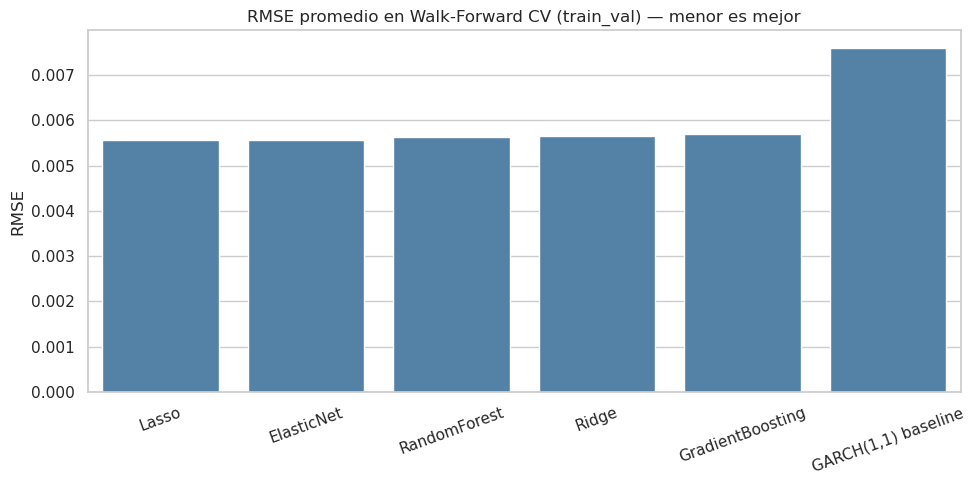

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
order = cv_summary.sort_values("mean_rmse")["modelo"]
sns.barplot(data=cv_summary, x="modelo", y="mean_rmse", order=order, ax=ax, color="steelblue")
ax.set_title("RMSE promedio en Walk-Forward CV (train_val) — menor es mejor")
ax.set_ylabel("RMSE"); ax.set_xlabel("")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### 5.2 Evaluación final en el holdout (RF17, RF19)

Este es el único momento en que tocamos `X_test` / `y_test`. Reentrenamos
cada modelo con su mejor configuración usando **todo** `train_val`, y lo
evaluamos **una sola vez** sobre el holdout — esta es la estimación más
honesta de cómo se comportaría cada modelo en producción.

In [30]:
best_params = {
    "Ridge": ridge_results.iloc[0]["params"],
    "Lasso": lasso_results.iloc[0]["params"],
    "ElasticNet": elasticnet_results.iloc[0]["params"],
    "RandomForest": rf_results.iloc[0]["params"],
    "GradientBoosting": gb_results.iloc[0]["params"],
}
model_ctors = {
    "Ridge": lambda p: Ridge(random_state=RANDOM_STATE, **p),
    "Lasso": lambda p: Lasso(random_state=RANDOM_STATE, max_iter=20000, **p),
    "ElasticNet": lambda p: ElasticNet(random_state=RANDOM_STATE, max_iter=20000, **p),
    "RandomForest": lambda p: RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **p),
    "GradientBoosting": lambda p: GradientBoostingRegressor(random_state=RANDOM_STATE, **p),
}
needs_scaling = {"Ridge": True, "Lasso": True, "ElasticNet": True, "RandomForest": False, "GradientBoosting": False}

holdout_predictions, final_results, fitted_models = {}, {}, {}

for name, ctor in model_ctors.items():
    X_tr, X_te = X_train_val, X_test
    scaler = None
    if needs_scaling[name]:
        scaler = StandardScaler().fit(X_tr)
        X_tr, X_te = scaler.transform(X_tr), scaler.transform(X_te)

    model = ctor(best_params[name])
    model.fit(X_tr, y_train_val)
    y_pred = model.predict(X_te)

    holdout_predictions[name] = y_pred
    fitted_models[name] = (model, scaler)
    final_results[name] = {
        "rmse": rmse(y_test, y_pred), "mae": mean_absolute_error(y_test, y_pred),
        **directional_bias_metrics(y_test, y_pred),
    }

# --- GARCH final, refit sobre todo train_val ---
# 1. Unimos la data de train_val y test para que GARCH avance día a día
combined_index = list(X_train_val.index) + list(X_test.index)
r_combined_full = df["sp500_log_return"].loc[combined_index] * 100

# 2. Instanciamos el modelo con la data combinada
am = arch_model(r_combined_full, vol="GARCH", p=1, q=1, dist="normal", mean="Zero", rescale=False)

# 3. FIT SOLO en entrenamiento (Evitamos el data leakage)
last_train_obs_full = len(X_train_val)
res = am.fit(last_obs=last_train_obs_full, disp="off")

# 4. Calibración in-sample
sigma_in_sample = res.conditional_volatility.iloc[:last_train_obs_full] / 100
calib = np.polyfit(sigma_in_sample, y_train_val.values, 1)

# 5. Predicción Out-of-Sample (1-step ahead a lo largo del test)
forecast = res.forecast(start=last_train_obs_full, reindex=False)
sigma_forecast = np.sqrt(forecast.variance.values.flatten()) / 100
y_pred_garch = np.polyval(calib, sigma_forecast)

holdout_predictions["GARCH(1,1) baseline"] = y_pred_garch
final_results["GARCH(1,1) baseline"] = {
    "rmse": rmse(y_test, y_pred_garch), 
    "mae": mean_absolute_error(y_test, y_pred_garch),
    **directional_bias_metrics(y_test, y_pred_garch),
}

final_table = pd.DataFrame(final_results).T.sort_values("rmse").reset_index().rename(columns={"index": "modelo"})
final_table

,modelo,rmse,mae,bias_medio,pct_subestimado,pct_sobreestimado,magnitud_media_subestimacion,magnitud_media_sobreestimacion
0,GradientBoosting,0.004845,0.003359,0.000593,34.482759,65.517241,0.004011,0.003016
1,RandomForest,0.004905,0.003357,0.000581,34.359606,65.640394,0.004039,0.003000
2,Ridge,0.005217,0.003425,0.000543,35.467980,64.532020,0.004062,0.003075
3,Lasso,0.005272,0.003472,0.000691,33.004926,66.995074,0.004213,0.003108
4,ElasticNet,0.005307,0.003495,0.000740,32.512315,67.487685,0.004236,0.003137
5,"GARCH(1,1) baseline",0.006075,0.003913,0.000688,36.330049,63.669951,0.004439,0.003613


### 5.3 Real vs. predicho en el holdout

Visualizamos el mejor modelo (menor RMSE en el holdout) contra GARCH y
el valor real, para inspeccionar cualitativamente si el modelo sigue los
picos de volatilidad o los suaviza en exceso.

Mejor modelo en el holdout: 0


KeyError: 0

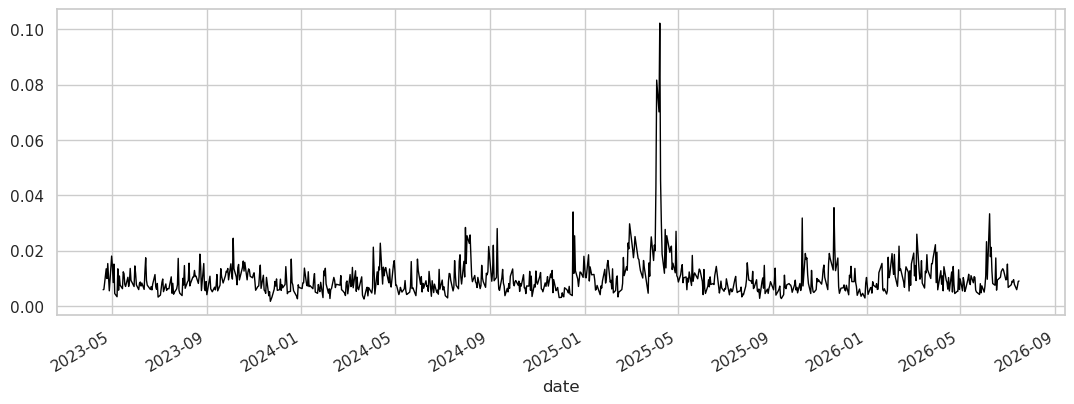

In [31]:
best_model_name = final_table.index[0]
print(f"Mejor modelo en el holdout: {best_model_name}")

fig, ax = plt.subplots(figsize=(13, 4.5))
y_test.plot(ax=ax, label="Real", color="black", linewidth=1)
pd.Series(holdout_predictions[best_model_name], index=y_test.index).plot(
    ax=ax, label=f"Predicción — {best_model_name}", linewidth=1)
pd.Series(holdout_predictions["GARCH(1,1) baseline"], index=y_test.index).plot(
    ax=ax, label="Predicción — GARCH(1,1)", linewidth=1, linestyle="--")
ax.set_title("Test holdout — real vs. predicho")
ax.legend()
plt.tight_layout()
plt.show()

### 5.4 Sesgo direccional (RF18)

Por cada modelo, qué porcentaje de días subestimó vs. sobreestimó la
volatilidad real. Un modelo con RMSE competitivo pero que subestima
sistemáticamente en más días es operacionalmente más riesgoso que uno con
RMSE ligeramente peor pero balanceado.

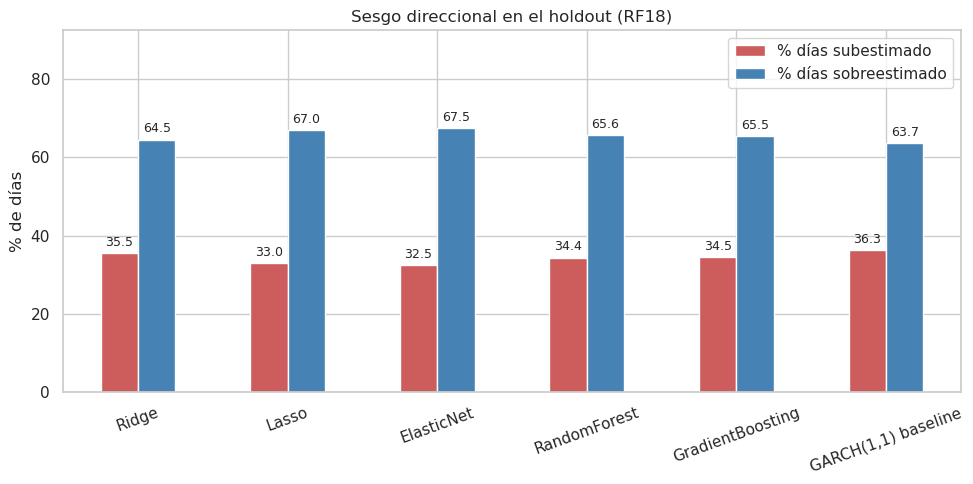

Magnitud media absoluta del error según su dirección:


,MAE_subestimando,MAE_sobreestimando
Ridge,0.004062,0.003075
Lasso,0.004213,0.003108
ElasticNet,0.004236,0.003137
RandomForest,0.004039,0.003000
GradientBoosting,0.004011,0.003016
"GARCH(1,1) baseline",0.004439,0.003613


In [26]:
# ==========================================
# 1. GRÁFICA CORREGIDA (Leyenda libre)
# ==========================================
bias_df = pd.DataFrame(final_results).T[["pct_subestimado", "pct_sobreestimado"]].astype(float)
ax = bias_df.plot(kind="bar", figsize=(10, 5), color=["indianred", "steelblue"])

# Ampliamos el límite del eje Y un 25% por encima del valor máximo para hacer espacio a la leyenda
max_val = bias_df.max().max()
ax.set_ylim(0, max_val + 25)

plt.title("Sesgo direccional en el holdout (RF18)")
plt.ylabel("% de días")
plt.xticks(rotation=20)
plt.legend(["% días subestimado", "% días sobreestimado"], loc="upper right")

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', label_type='edge', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

# ==========================================
# 2. CÁLCULO DEL MAE DIRECCIONAL
# ==========================================
directional_metrics = {}

for name, y_pred in holdout_predictions.items():
    # Error real = Valor Real - Predicción
    # Si es positivo: El modelo predijo de menos (subestimó)
    # Si es negativo: El modelo predijo de más (sobreestimó)
    error = y_test - y_pred 
    
    err_under = error[error > 0]
    err_over = error[error < 0]
    
    directional_metrics[name] = {
        "MAE_subestimando": err_under.abs().mean() if not err_under.empty else 0.0,
        "MAE_sobreestimando": err_over.abs().mean() if not err_over.empty else 0.0,
    }

df_directional_mae = pd.DataFrame(directional_metrics).T
print("Magnitud media absoluta del error según su dirección:")
display(df_directional_mae)

In [ ]:
# ==========================================================
# CÁLCULO DE MÉTRICAS DIRECCIONALES (MAE, RMSE, MAX ERROR)
# ==========================================================
directional_metrics = {}

for name, y_pred in holdout_predictions.items():
    # Error = Real - Predicción
    # Positivo (> 0): El modelo subestimó la volatilidad
    # Negativo (< 0): El modelo sobreestimó la volatilidad
    error = y_test - y_pred 
    
    err_under = error[error > 0]
    err_over = error[error < 0]
    
    directional_metrics[name] = {
        # Mean Absolute Error (MAE) - Promedio del error
        "MAE_subest": err_under.abs().mean() if not err_under.empty else 0.0,
        "MAE_sobreest": err_over.abs().mean() if not err_over.empty else 0.0,
        
        # Root Mean Squared Error (RMSE) - Penaliza errores grandes
        "RMSE_subest": np.sqrt((err_under**2).mean()) if not err_under.empty else 0.0,
        "RMSE_sobreest": np.sqrt((err_over**2).mean()) if not err_over.empty else 0.0,
        
        # Maximum Error (MaxErr) - El peor escenario absoluto
        "MaxErr_subest": err_under.abs().max() if not err_under.empty else 0.0,
        "MaxErr_sobreest": err_over.abs().max() if not err_over.empty else 0.0,
    }

# Transponemos y redondeamos a 6 decimales para facilitar la lectura
df_directional_metrics = pd.DataFrame(directional_metrics).T.round(6)

print("Métricas de Error Direccional en el Holdout:")
display(df_directional_metrics)

Métricas de Error Direccional en el Holdout:


,MAE_subest,MAE_sobreest,RMSE_subest,RMSE_sobreest,MaxErr_subest,MaxErr_sobreest
Ridge,0.004062,0.003075,0.006993,0.003912,0.056670,0.021022
Lasso,0.004213,0.003108,0.007348,0.003859,0.060102,0.019177
ElasticNet,0.004236,0.003137,0.007477,0.003847,0.061267,0.018235
RandomForest,0.004039,0.003000,0.006590,0.003731,0.046746,0.017231
GradientBoosting,0.004011,0.003016,0.006374,0.003800,0.041479,0.022231
"GARCH(1,1) baseline",0.004439,0.003613,0.007987,0.004644,0.072700,0.027598


In [ ]:
# ==========================================================
# CÁLCULO DE MÉTRICAS EN PUNTOS PORCENTUALES (%)
# ==========================================================
directional_metrics_pct = {}

for name, y_pred in holdout_predictions.items():
    # Multiplicamos el error original por 100 para pasarlo a porcentaje
    error_pct = (y_test - y_pred) * 100 
    
    err_under_pct = error_pct[error_pct > 0]
    err_over_pct = error_pct[error_pct < 0]
    
    directional_metrics_pct[name] = {
        "MAE_subest_(%)": err_under_pct.abs().mean() if not err_under_pct.empty else 0.0,
        "MAE_sobreest_(%)": err_over_pct.abs().mean() if not err_over_pct.empty else 0.0,
        
        "MaxErr_subest_(%)": err_under_pct.abs().max() if not err_under_pct.empty else 0.0,
        "MaxErr_sobreest_(%)": err_over_pct.abs().max() if not err_over_pct.empty else 0.0,
    }

# Redondeamos a 3 decimales para leerlo fácilmente
df_metrics_pct = pd.DataFrame(directional_metrics_pct).T.round(3)

print("Métricas de Error Direccional en PORCENTAJE DE VOLATILIDAD (%):")
display(df_metrics_pct)

Métricas de Error Direccional en PORCENTAJE DE VOLATILIDAD (%):


,MAE_subest_(%),MAE_sobreest_(%),MaxErr_subest_(%),MaxErr_sobreest_(%)
Ridge,0.406,0.307,5.667,2.102
Lasso,0.421,0.311,6.010,1.918
ElasticNet,0.424,0.314,6.127,1.823
RandomForest,0.404,0.300,4.675,1.723
GradientBoosting,0.401,0.302,4.148,2.223
"GARCH(1,1) baseline",0.444,0.361,7.270,2.760


In [36]:

# 1. Definimos el umbral del VIX y lo pasamos a logaritmo natural
vix_threshold_raw = 25
vix_threshold_log = np.log(vix_threshold_raw)

# 2. Extraemos el VIX del set de test y creamos las máscaras booleanas
vix_test = df["vix_log_close"].loc[y_test.index]

mask_normal = vix_test <= vix_threshold_log
mask_crisis = vix_test > vix_threshold_log

# 3. Calculamos el MAE en porcentaje para cada modelo bajo ambos regímenes
regime_metrics = {}

for name, y_pred in holdout_predictions.items():
    # Convertimos la predicción a Serie de Pandas para alinear los índices con las máscaras
    y_pred_series = pd.Series(y_pred, index=y_test.index)
    
    # Filtramos la data real y la predicha usando las máscaras
    y_test_normal, y_pred_normal = y_test[mask_normal], y_pred_series[mask_normal]
    y_test_crisis, y_pred_crisis = y_test[mask_crisis], y_pred_series[mask_crisis]
    
    # Calculamos el MAE (* 100 para verlo en porcentaje)
    mae_normal = mean_absolute_error(y_test_normal, y_pred_normal) * 100 if not y_test_normal.empty else np.nan
    mae_crisis = mean_absolute_error(y_test_crisis, y_pred_crisis) * 100 if not y_test_crisis.empty else np.nan
    
    regime_metrics[name] = {
        "MAE_Normal (<=25) %": mae_normal,
        "MAE_Crisis (>25) %": mae_crisis,
        "Días Normal": int(mask_normal.sum()),
        "Días Crisis": int(mask_crisis.sum())
    }

# 4. Mostramos la tabla final
df_regime_metrics = pd.DataFrame(regime_metrics).T.round(3)
print(f"Análisis de error (MAE) según el régimen del VIX (Umbral: {vix_threshold_raw}):")
display(df_regime_metrics)

Análisis de error (MAE) según el régimen del VIX (Umbral: 25):


,MAE_Normal (<=25) %,MAE_Crisis (>25) %,Días Normal,Días Crisis
Ridge,0.315,0.910,774.0,38.0
Lasso,0.320,0.898,774.0,38.0
ElasticNet,0.323,0.891,774.0,38.0
RandomForest,0.310,0.854,774.0,38.0
GradientBoosting,0.311,0.841,774.0,38.0
"GARCH(1,1) baseline",0.355,1.136,774.0,38.0


In [39]:
import numpy as np
import pandas as pd

# ==========================================================
# CÁLCULO COMPARATIVO: DIRECCIONAL GLOBAL VS RÉGIMEN (%)
# ==========================================================
vix_threshold_raw = 25
vix_threshold_log = np.log(vix_threshold_raw)

# Extraemos el VIX alineado
vix_test = df["vix_log_close"].loc[y_test.index]

mask_normal = vix_test <= vix_threshold_log
mask_crisis = vix_test > vix_threshold_log

directional_comparison = {}

for name, y_pred in holdout_predictions.items():
    y_pred_series = pd.Series(y_pred, index=y_test.index)
    
    # 1. Error GLOBAL (Todo el Holdout)
    error_global = (y_test - y_pred_series) * 100
    err_under_glob = error_global[error_global > 0]
    err_over_glob  = error_global[error_global < 0]
    
    # 2. Error NORMAL (VIX <= 25)
    error_normal = (y_test[mask_normal] - y_pred_series[mask_normal]) * 100
    err_under_norm = error_normal[error_normal > 0]
    err_over_norm  = error_normal[error_normal < 0]
    
    # 3. Error CRISIS (VIX > 25)
    error_crisis = (y_test[mask_crisis] - y_pred_series[mask_crisis]) * 100
    err_under_cris = error_crisis[error_crisis > 0]
    err_over_cris  = error_crisis[error_crisis < 0]
    
    directional_comparison[name] = {
        # --- MAE SUBESTIMADO (El modelo predijo de menos) ---
        "Global_MAE_subest(%)": err_under_glob.abs().mean() if not err_under_glob.empty else 0.0,
        "Norm_MAE_subest(%)": err_under_norm.abs().mean() if not err_under_norm.empty else 0.0,
        "Cris_MAE_subest(%)": err_under_cris.abs().mean() if not err_under_cris.empty else 0.0,
        
        # --- MAE SOBREESTIMADO (El modelo predijo de más) ---
        "Global_MAE_sobreest(%)": err_over_glob.abs().mean() if not err_over_glob.empty else 0.0,
        "Norm_MAE_sobreest(%)": err_over_norm.abs().mean() if not err_over_norm.empty else 0.0,
        "Cris_MAE_sobreest(%)": err_over_cris.abs().mean() if not err_over_cris.empty else 0.0,
        
        # --- RMSE SUBESTIMADO (Penaliza errores grandes al quedarse corto) ---
        "Global_RMSE_subest(%)": np.sqrt((err_under_glob**2).mean()) if not err_under_glob.empty else 0.0,
        "Norm_RMSE_subest(%)": np.sqrt((err_under_norm**2).mean()) if not err_under_norm.empty else 0.0,
        "Cris_RMSE_subest(%)": np.sqrt((err_under_cris**2).mean()) if not err_under_cris.empty else 0.0,
        
        # --- RMSE SOBREESTIMADO (Penaliza errores grandes al pasarse) ---
        "Global_RMSE_sobreest(%)": np.sqrt((err_over_glob**2).mean()) if not err_over_glob.empty else 0.0,
        "Norm_RMSE_sobreest(%)": np.sqrt((err_over_norm**2).mean()) if not err_over_norm.empty else 0.0,
        "Cris_RMSE_sobreest(%)": np.sqrt((err_over_cris**2).mean()) if not err_over_cris.empty else 0.0,
    }

# Transponemos y redondeamos a 3 decimales
df_dir_comparison = pd.DataFrame(directional_comparison).T.round(3)

print(f"Comparativa Direccional: Global vs Regímenes (Umbral VIX: {vix_threshold_raw})")
display(df_dir_comparison)

Comparativa Direccional: Global vs Regímenes (Umbral VIX: 25)


,Global_MAE_subest(%),Norm_MAE_subest(%),Cris_MAE_subest(%),Global_MAE_sobreest(%),Norm_MAE_sobreest(%),Cris_MAE_sobreest(%),Global_RMSE_subest(%),Norm_RMSE_subest(%),Cris_RMSE_subest(%),Global_RMSE_sobreest(%),Norm_RMSE_sobreest(%),Cris_RMSE_sobreest(%)
Ridge,0.406,0.362,1.640,0.307,0.288,0.649,0.699,0.533,2.490,0.391,0.350,0.832
Lasso,0.421,0.372,1.574,0.311,0.294,0.623,0.735,0.543,2.502,0.386,0.354,0.779
ElasticNet,0.424,0.370,1.795,0.314,0.300,0.568,0.748,0.543,2.696,0.385,0.357,0.729
RandomForest,0.404,0.368,1.278,0.300,0.280,0.682,0.659,0.535,2.009,0.373,0.333,0.816
GradientBoosting,0.401,0.371,1.412,0.302,0.278,0.688,0.637,0.537,2.099,0.380,0.332,0.847
"GARCH(1,1) baseline",0.444,0.385,1.294,0.361,0.338,0.978,0.799,0.564,2.297,0.464,0.406,1.248


### 5.5 Conclusiones de la Fase 5

- La tabla `final_table` (5.2) es la comparación oficial pedida por RF19:
  RMSE, MAE de cada modelo ML contra el baseline GARCH, en datos que
  ningún modelo vio durante la selección de hiperparámetros.
- `cv_summary` (5.1) muestra qué tan estable fue cada modelo entre folds
  (columna `std_rmse`) — relevante para decidir si un resultado del
  holdout es "suerte" o consistente con lo visto en walk-forward.
- La gráfica de sesgo direccional (5.4) es el insumo que pide RF18 para
  no evaluar los modelos solo por error promedio.

**Con estas tres tablas/gráficas tienes todo lo necesario para elegir el
modelo ganador.** Cuéntame cuál prefieres (o el criterio que quieras
priorizar: menor RMSE, menor subestimación, mejor estabilidad entre
folds) y con eso construimos el script de reentrenamiento automático.


## Fase 6 — Despliegue (Deployment)

Esta fase se completa en el **próximo pipeline** (script de
reentrenamiento, RF08), una vez que definamos el modelo ganador. Lo que
ya queda listo desde este notebook:

- **RF07** (exportar el modelo entrenado en `.pkl` desde Jupyter): función
  `save_model_version()` abajo, ya funcional.
- **RF11** (versionar cada modelo: timestamp, hiperparámetros, métricas de
  validación): el mismo artefacto `.pkl` incluye ese metadato, listo para
  que `PipelineManager.check_retraining_needed()` lo lea (`last_trained`,
  igual que hoy usa `model_metadata.pkl`).

Lo que **falta** y se construirá cuando confirmes el modelo ganador:
- **RF08**: automatizar este mismo ciclo de walk-forward + refit dentro de
  un script ejecutable con periodicidad configurable (mensual por
  defecto), en vez de correrlo manualmente desde el notebook.
- **RF13**: mecanismo para reemplazar el modelo vigente en producción sin
  downtime.
- **RNF04**: conservar el `.pkl` anterior como respaldo si el
  reentrenamiento produce métricas peores que el modelo vigente.

Por ahora, como demostración de RF07/RF11, guardamos el mejor modelo del
holdout en una carpeta de *staging* (no en `models/artifacts/`, esa
ruta la reserva `PipelineManager` para el modelo oficial en producción).

In [40]:
def save_model_version(model, scaler, model_name: str, metrics: dict, params: dict, output_dir: Path) -> Path:
    # RF07: exporta el modelo entrenado en .pkl desde el entorno de experimentación.
    # RF11: versiona el artefacto con timestamp, hiperparámetros y métricas
    # de validación, para trazabilidad y rollback a una versión anterior.
    output_dir.mkdir(parents=True, exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    artifact = {
        "model": model,
        "scaler": scaler,
        "model_name": model_name,
        "feature_columns": feature_columns,
        "schema_version": SCHEMA_VERSION,
        "last_trained": datetime.now().strftime("%Y-%m-%d"),
        "trained_at": timestamp,
        "hyperparameters": params,
        "validation_metrics": metrics,
    }
    path = output_dir / f"{model_name}_{timestamp}.pkl"
    joblib.dump(artifact, path)
    return path


demo_path = save_model_version(
    model=fitted_models[best_model_name][0],
    scaler=fitted_models[best_model_name][1],
    model_name=best_model_name,
    metrics=final_results[best_model_name],
    params=best_params.get(best_model_name, {}),
    output_dir=SRC_DIR.parent / "models" / "artifacts_staging",
)
print(f"Modelo de ejemplo guardado en: {demo_path}")

KeyError: 0

## Resumen y próximos pasos

1. Revisa `final_table` (5.2) y las gráficas de la Fase 5 con calma.
2. Dime qué modelo prefieres para producción (y bajo qué criterio).
3. Con esa decisión, construimos:
   - El script de reentrenamiento automático con Walk-Forward (RF08).
   - El versionado formal en `models/artifacts/` + `model_metadata.pkl`
     (integrado con el `PipelineManager` que ya existe).
   - El mecanismo de reemplazo sin downtime (RF13) y el respaldo ante
     fallas de reentrenamiento (RNF04).
